In [10]:
#!pip3 install pandas
# Import necessary library
import pandas as pd
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()

# Convert to DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Display the first few rows of the dataframe
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [11]:
# Rename the columns with abbreviated names
iris_df.columns = ['SL', 'SW', 'PL', 'PW']
iris_df.head()

,SL,SW,PL,PW
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
# Assuming the species column is in the original iris dataset but not included in iris_df
# First, add the species column to iris_df
iris_df['Species'] = iris.target

# Now, check how many different species are there
unique_species = iris_df['Species'].unique()
num_unique_species = len(unique_species)

print(f"Number of different species: {num_unique_species}")
print(f"Species IDs: {unique_species}")


Number of different species: 3
Species IDs: [0 1 2]


In [9]:
# Quick overview of the dataset
print("Dataset Info:")
print(iris_df.info())

print("\nFirst 5 Rows:")
print(iris_df.head())

print("\nSummary Statistics:")
print(iris_df.describe())

print("\nCount of Each Species:")
print(iris_df['Species'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SL       150 non-null    float64
 1   SW       150 non-null    float64
 2   PL       150 non-null    float64
 3   PW       150 non-null    float64
 4   Species  150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None

First 5 Rows:
    SL   SW   PL   PW  Species
0  5.1  3.5  1.4  0.2        0
1  4.9  3.0  1.4  0.2        0
2  4.7  3.2  1.3  0.2        0
3  4.6  3.1  1.5  0.2        0
4  5.0  3.6  1.4  0.2        0

Summary Statistics:
               SL          SW          PL          PW     Species
count  150.000000  150.000000  150.000000  150.000000  150.000000
mean     5.843333    3.057333    3.758000    1.199333    1.000000
std      0.828066    0.435866    1.765298    0.762238    0.819232
min      4.300000    2.000000    1.000000    0.100000    0.000000
25%      

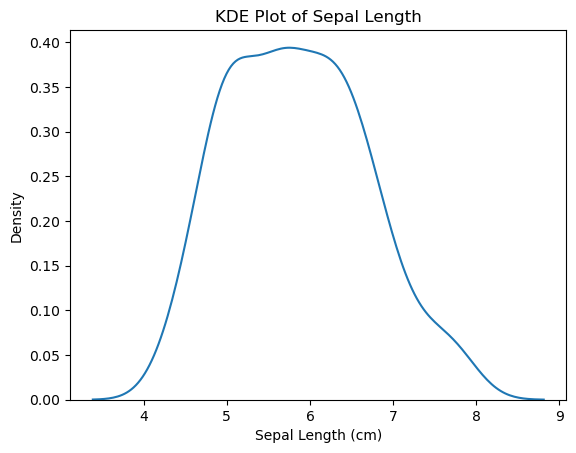

In [13]:
# Import necessary library
import seaborn as sns
import matplotlib.pyplot as plt

# KDE plot for the Sepal Length feature
sns.kdeplot(data=iris_df, x="SL")
plt.title('KDE Plot of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.show()

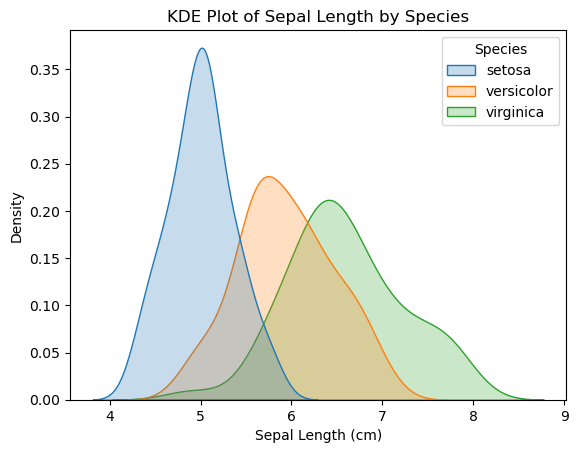

In [14]:
# Map the species IDs back to species names for clarity
species_mapping = dict(zip(range(len(iris.target_names)), iris.target_names))
iris_df['Species'] = iris_df['Species'].map(species_mapping)

# KDE plot for the Sepal Length feature for each species
sns.kdeplot(data=iris_df, x="SL", hue="Species", fill=True)
plt.title('KDE Plot of Sepal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.show()

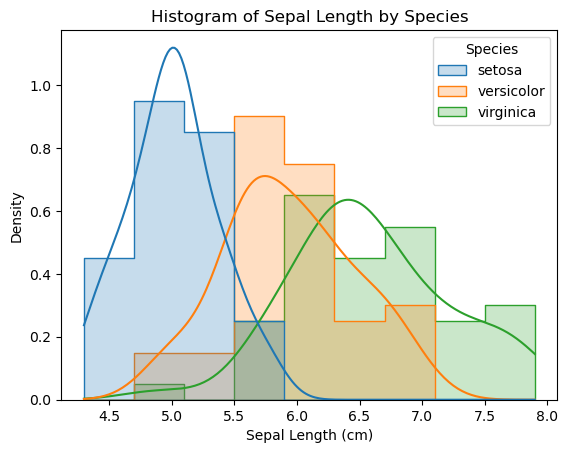

In [15]:
# Histogram plot for the Sepal Length feature for each species
sns.histplot(data=iris_df, x="SL", hue="Species", kde=True, element="step", stat="density", common_norm=False)
plt.title('Histogram of Sepal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Prepare the Data
X = iris_df[['SL', 'SW', 'PL', 'PW']]  # Features
y = iris_df['Species']  # Target

# 2. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Select a Model
model = RandomForestClassifier(n_estimators=100)

# 4. Train the Model
model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# 6. Predictions (Example)
# Predict the species of a new flower with SL=5, SW=3, PL=1.5, PW=0.4
new_flower = [[5, 3, 1.5, 0.4]]
prediction = model.predict(new_flower)
print(f"Predicted Species: {prediction[0]}")

Accuracy: 1.0
Predicted Species: setosa


c:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


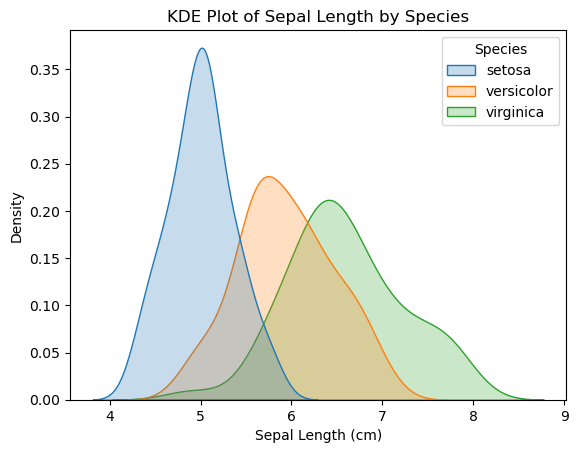

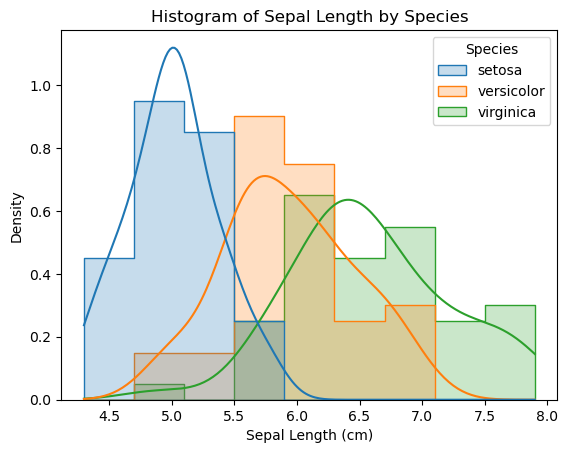

Accuracy: 1.0
Predicted Species: setosa


c:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.columns = ['SL', 'SW', 'PL', 'PW']  # Rename columns with abbreviated names
iris_df['Species'] = iris.target  # Add species column

# Map species IDs to names for clarity
species_mapping = dict(zip(range(len(iris.target_names)), iris.target_names))
iris_df['Species'] = iris_df['Species'].map(species_mapping)

# KDE plot for Sepal Length by Species
sns.kdeplot(data=iris_df, x="SL", hue="Species", fill=True)
plt.title('KDE Plot of Sepal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.show()

# Histogram plot for Sepal Length by Species
sns.histplot(data=iris_df, x="SL", hue="Species", kde=True, element="step", stat="density", common_norm=False)
plt.title('Histogram of Sepal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.show()

# Prepare the data for machine learning model
X = iris_df[['SL', 'SW', 'PL', 'PW']]  # Features
y = iris_df['Species']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Select and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Predict the species of a new flower
new_flower = [[5, 3, 1.5, 0.4]]
prediction = model.predict(new_flower)
print(f"Predicted Species: {prediction[0]}")

In [ ]:
# demo_inline.ipynb

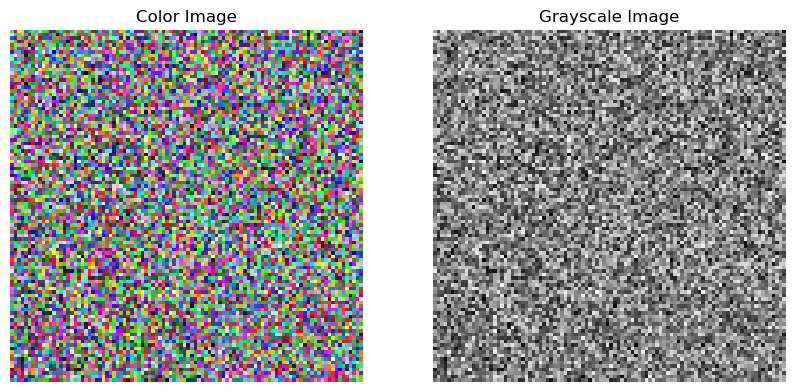

In [18]:
import numpy as np

import matplotlib.pyplot as plt

# Create a random color image
random_image = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)

# Convert the color image to grayscale
grayscale_image = np.dot(random_image[..., :3], [0.2989, 0.5870, 0.1140])

# Display the images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(random_image)
axes[0].set_title('Color Image')
axes[0].axis('off')
axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title('Grayscale Image')
axes[1].axis('off')

plt.show()

In [ ]:
import cv2

def convert_to_grayscale(color_image):
    """
    Converts a color image to grayscale.

    Parameters:
    color_image (numpy.ndarray): The input color image.

    Returns:
    numpy.ndarray: The grayscale image.
    """
    grayscale_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
    return grayscale_image

In [ ]:
## problems

In [23]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def sortedArrayToBST(nums):
    if not nums:
        return None
    mid = len(nums) // 2
    root = TreeNode(nums[mid])
    root.left = sortedArrayToBST(nums[:mid])
    root.right = sortedArrayToBST(nums[mid+1:])
    return root

# Example sorted array
nums = [-10, -3, 0, 5, 9]

# Convert the sorted array to a balanced binary tree
tree_root = sortedArrayToBST(nums)

# Function to print the tree in order (just for demonstration)
def printInOrder(node):
    if not node:
        return
    printInOrder(node.left)
    print(node.val, end=' ')
    printInOrder(node.right)

# Print the balanced binary tree
printInOrder(tree_root)

-10 -3 0 5 9 

In [24]:

def printTree(node, prefix="", isLeft=True):
    if node:
        printTree(node.right, prefix + ("│   " if isLeft else "    "), False)
        print(prefix + ("└── " if isLeft else "┌── ") + str(node.val))
        printTree(node.left, prefix + ("    " if isLeft else "│   "), True)

# Print the balanced binary tree in a visual way
printTree(tree_root)

│   ┌── 9
│   │   └── 5
└── 0
    └── -3
        └── -10


In [26]:
# Test case 1
nums1 = [1, 2, 3, 4, 5]
tree_root1 = sortedArrayToBST(nums1)
print("Test Case 1:")
printTree(tree_root1)
print("\n")

# Test case 2
nums2 = [-10, -3, 0, 5, 9]
tree_root2 = sortedArrayToBST(nums2)
print("Test Case 2:")
printTree(tree_root2)
print("\n")

# Test case 3
nums3 = [1]
tree_root3 = sortedArrayToBST(nums3)
print("Test Case 3:")
printTree(tree_root3)
print("\n")

# Test case 4
nums4 = []
tree_root4 = sortedArrayToBST(nums4)
print("Test Case 4:")
if tree_root4:
    printTree(tree_root4)
else:
    print("Empty tree")
print("\n")

Test Case 1:
│   ┌── 5
│   │   └── 4
└── 3
    └── 2
        └── 1


Test Case 2:
│   ┌── 9
│   │   └── 5
└── 0
    └── -3
        └── -10


Test Case 3:
└── 1


Test Case 4:
Empty tree




In [27]:
def twoSumBruteForce(nums, target):
    for i in range(len(nums)):
        for j in range(i + 1, len(nums)):
            if nums[i] + nums[j] == target:
                return [i, j]
            
def twoSumHashMap(nums, target):
    num_map = {}
    for i, num in enumerate(nums):
        complement = target - num
        if complement in num_map:
            return [num_map[complement], i]
        num_map[num] = i

def twoSumSorting(nums, target):
    nums = sorted(enumerate(nums), key=lambda x: x[1])
    left, right = 0, len(nums) - 1
    while left < right:
        current_sum = nums[left][1] + nums[right][1]
        if current_sum == target:
            return [nums[left][0], nums[right][0]]
        elif current_sum < target:
            left += 1
        else:
            right -= 1

In [28]:
test_cases = [([2, 7, 11, 15], 9, [0, 1]),
              ([-3, 4, 3, 90], 0, [0, 2]),
              ([0, 1, 2, -3], -3, [0, 3]),
              ([5, 5, 1, 7, 2, 3, 5], 10, [0, 3]),  # Note: Expected output may vary based on implementation
              ([1, 2, 3, 4, 5], 20, None)]  # None or equivalent if no solution

def test_two_sum_functions(functions, test_cases):
    for func in functions:
        print(f"Testing {func.__name__}:")
        for nums, target, expected in test_cases:
            result = func(nums, target)
            if expected is None:
                assert result is None, f"Expected None, got {result}"
            else:
                assert sum(nums[i] for i in result) == target, f"Expected sum {target}, got {sum(nums[i] for i in result)}"
            print(f"Passed: nums={nums}, target={target}, expected={expected}, got={result}")
        print()

# Assuming the functions are defined as twoSumBruteForce, twoSumHashMap, twoSumSorting
test_two_sum_functions([twoSumBruteForce, twoSumHashMap, twoSumSorting], test_cases)

Testing twoSumBruteForce:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1]
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2]
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3]
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=10, expected=[0, 3], got=[0, 1]
Passed: nums=[1, 2, 3, 4, 5], target=20, expected=None, got=None

Testing twoSumHashMap:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1]
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2]
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3]
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=10, expected=[0, 3], got=[0, 1]
Passed: nums=[1, 2, 3, 4, 5], target=20, expected=None, got=None

Testing twoSumSorting:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1]
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2]
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[3, 0]
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=

In [30]:
import time

def test_two_sum_functions(functions, test_cases):
    for func in functions:
        print(f"Testing {func.__name__}:")
        total_time = 0
        for nums, target, expected in test_cases:
            start_time = time.time()
            result = func(nums, target)
            end_time = time.time()
            elapsed_time = end_time - start_time
            total_time += elapsed_time
            
            if expected is None:
                assert result is None, f"Expected None, got {result}"
            else:
                assert sum(nums[i] for i in result) == target, f"Expected sum {target}, got {sum(nums[i] for i in result)}"
            print(f"Passed: nums={nums}, target={target}, expected={expected}, got={result}, time={elapsed_time:.6f} seconds")
        
        print(f"Total time for {func.__name__}: {total_time:.6f} seconds\n")

test_two_sum_functions([twoSumBruteForce, twoSumHashMap, twoSumSorting], test_cases)

Testing twoSumBruteForce:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1], time=0.000000 seconds
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2], time=0.000000 seconds
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3], time=0.000000 seconds
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=10, expected=[0, 3], got=[0, 1], time=0.000000 seconds
Passed: nums=[1, 2, 3, 4, 5], target=20, expected=None, got=None, time=0.000000 seconds
Total time for twoSumBruteForce: 0.000000 seconds

Testing twoSumHashMap:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1], time=0.000000 seconds
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2], time=0.000000 seconds
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3], time=0.000000 seconds
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=10, expected=[0, 3], got=[0, 1], time=0.000000 seconds
Passed: nums=[1, 2, 3, 4, 5], target=20, expected=None, got=None, time=0.000

In [31]:
import timeit

def test_two_sum_functions(functions, test_cases, number=1000):
    for func in functions:
        print(f"Testing {func.__name__}:")
        total_time = 0
        for nums, target, expected in test_cases:
            # Prepare the function call as a string to be executed by timeit
            stmt = f"{func.__name__}({nums}, {target})"
            # Set up the environment for the timeit execution
            setup = f"from __main__ import {func.__name__}"
            # Measure the time
            elapsed_time = timeit.timeit(stmt, setup=setup, number=number) / number
            total_time += elapsed_time
            
            # Execute the function once to check the result (outside of timing)
            result = func(nums, target)
            if expected is None:
                assert result is None, f"Expected None, got {result}"
            else:
                assert sum(nums[i] for i in result) == target, f"Expected sum {target}, got {sum(nums[i] for i in result)}"
            print(f"Passed: nums={nums}, target={target}, expected={expected}, got={result}, avg time={elapsed_time:.6f} seconds over {number} runs")
        
        print(f"Total avg time for {func.__name__}: {total_time:.6f} seconds\n")

# Assuming the functions and test_cases are defined
test_two_sum_functions([twoSumBruteForce, twoSumHashMap, twoSumSorting], test_cases)

Testing twoSumBruteForce:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1], avg time=0.000005 seconds over 1000 runs
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2], avg time=0.000003 seconds over 1000 runs
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3], avg time=0.000003 seconds over 1000 runs
Passed: nums=[5, 5, 1, 7, 2, 3, 5], target=10, expected=[0, 3], got=[0, 1], avg time=0.000003 seconds over 1000 runs
Passed: nums=[1, 2, 3, 4, 5], target=20, expected=None, got=None, avg time=0.000015 seconds over 1000 runs
Total avg time for twoSumBruteForce: 0.000029 seconds

Testing twoSumHashMap:
Passed: nums=[2, 7, 11, 15], target=9, expected=[0, 1], got=[0, 1], avg time=0.000007 seconds over 1000 runs
Passed: nums=[-3, 4, 3, 90], target=0, expected=[0, 2], got=[0, 2], avg time=0.000006 seconds over 1000 runs
Passed: nums=[0, 1, 2, -3], target=-3, expected=[0, 3], got=[0, 3], avg time=0.000011 seconds over 1000 runs
Passed: nums=[5, 5

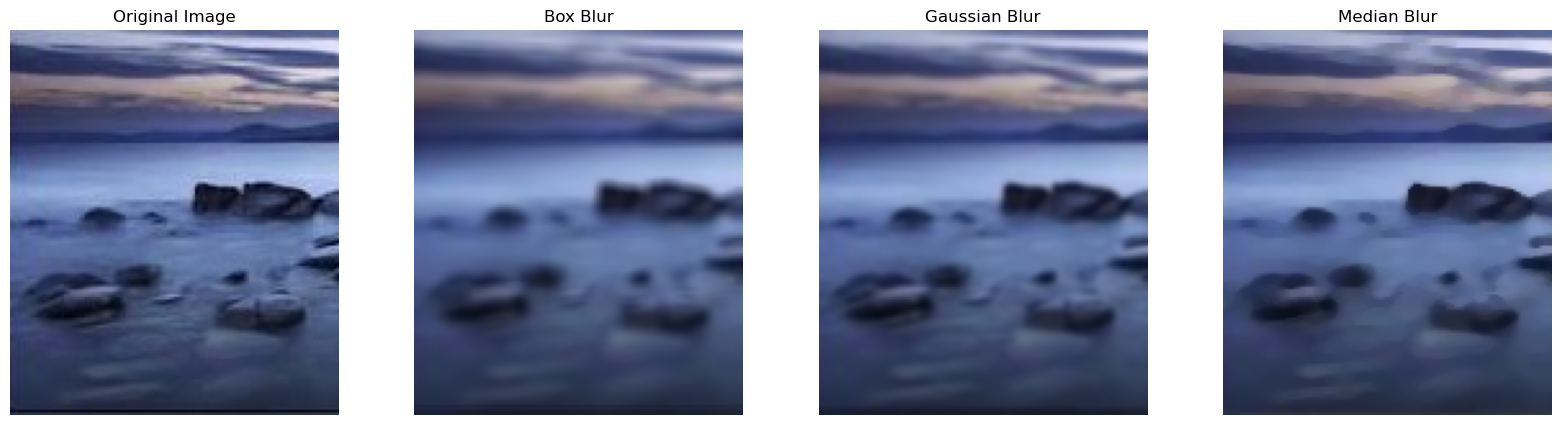

In [37]:
#!pip install opencv-python matplotlib
import cv2
import matplotlib.pyplot as plt

# Load an image
image_path = 'im.jpg'
image = cv2.imread(image_path)
# Convert BGR image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Box Blur (Averaging)
box_blur = cv2.blur(image_rgb, (5, 5))  # The second parameter is the kernel size

# Gaussian Blur
gaussian_blur = cv2.GaussianBlur(image_rgb, (5, 5), 0)  # Kernel size and sigmaX value

# Median Blur
median_blur = cv2.medianBlur(image_rgb, 5)  # The second parameter is the kernel size, which must be an odd number

# Plotting the images side by side using matplotlib
fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')  # Hide the axis

axs[1].imshow(box_blur)
axs[1].set_title('Box Blur')
axs[1].axis('off')

axs[2].imshow(gaussian_blur)
axs[2].set_title('Gaussian Blur')
axs[2].axis('off')

axs[3].imshow(median_blur)
axs[3].set_title('Median Blur')
axs[3].axis('off')

plt.show()

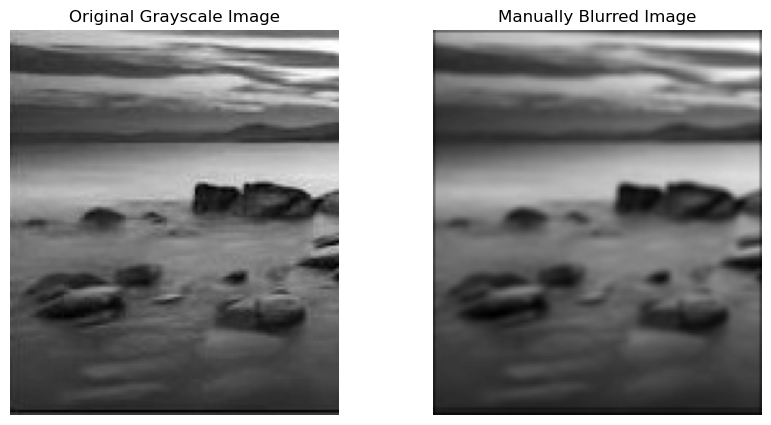

In [38]:
def manual_box_blur(grayscale_img, kernel_size=3):
    # Ensure kernel size is odd to have a central pixel
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd")
    
    # Calculate the padding width
    pad_width = kernel_size // 2
    
    # Pad the original image with zeros on all sides
    padded_img = np.pad(grayscale_img, pad_width, mode='constant', constant_values=0)
    
    # Prepare the output image
    blurred_img = np.zeros_like(grayscale_img)
    
    # Compute the blur
    for i in range(grayscale_img.shape[0]):  # Iterate over rows
        for j in range(grayscale_img.shape[1]):  # Iterate over columns
            # Calculate the average of the neighborhood
            blurred_img[i, j] = np.mean(padded_img[i:i+kernel_size, j:j+kernel_size])
    
    return blurred_img.astype(np.uint8)

# Example usage
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'image_rgb' is the loaded image from the previous code snippet
# Convert to grayscale for simplicity
grayscale_img = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Apply the manual box blur
blurred_image = manual_box_blur(grayscale_img, kernel_size=3)

# Display the original and blurred images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Manually Blurred Image')
plt.axis('off')

plt.show()